In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import zipfile
import os

zip_path = '/content/drive/MyDrive/ML/Datasets/realwaste.zip'
extract_path = '/content/realwaste_dataset'

# Create extraction folder if it doesn’t exist
os.makedirs(extract_path, exist_ok=True)

# Extract dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")
print("Extracted to:", extract_path)


✅ Dataset extracted successfully!
Extracted to: /content/realwaste_dataset


In [3]:
import os
import shutil
import random

source_dir = '/content/realwaste_dataset/realwaste-main/RealWaste'
base_dir = '/content/realwaste_split'  # new folder to store the split dataset

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Create directories
for dir_path in [train_dir, val_dir, test_dir]:
    os.makedirs(dir_path, exist_ok=True)

#Split the data
split_ratio = {'train': 0.7, 'val': 0.15, 'test': 0.15}

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # List all images in the class
    images = os.listdir(class_path)
    random.shuffle(images)

    # Compute split indices
    total = len(images)
    train_count = int(split_ratio['train'] * total)
    val_count = int(split_ratio['val'] * total)

    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count + val_count]
    test_imgs = images[train_count + val_count:]

    # Create subdirectories for the class in train/val/test
    for split, img_list in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        split_class_dir = os.path.join(base_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        # Copy images to new directories
        for img in img_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy2(src, dst)

    print(f" {class_name}: {train_count} train, {val_count} val, {len(test_imgs)} test")

print("\n Dataset successfully split into train, val, and test folders!")
print("Root directory:", base_dir)


 Plastic: 644 train, 138 val, 139 test
 Paper: 350 train, 75 val, 75 test
 Textile Trash: 222 train, 47 val, 49 test
 Vegetation: 305 train, 65 val, 66 test
 Glass: 294 train, 63 val, 63 test
 Cardboard: 322 train, 69 val, 70 test
 Miscellaneous Trash: 346 train, 74 val, 75 test
 Food Organics: 287 train, 61 val, 63 test
 Metal: 553 train, 118 val, 119 test

 Dataset successfully split into train, val, and test folders!
Root directory: /content/realwaste_split


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import copy
import matplotlib.pyplot as plt


In [5]:
# Data augmentation & normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128,128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.2,0.2,0.2,0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])
}

data_dir = '/content/realwaste_split'  # Update path

image_datasets = {x: datasets.ImageFolder(f"{data_dir}/{x}", transform=data_transforms[x])
                  for x in ['train','val','test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=16, shuffle=True, num_workers=2)
               for x in ['train','val','test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train','val','test']}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [9]:
import torch
import torch.nn as nn

class CNN_model_5conv_WasteStyle(nn.Module):
    def __init__(self, in_channel=3, num_classes=9):
        super().__init__()

        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channel, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.01, inplace=True),
            nn.AdaptiveAvgPool2d((8,8))  # adaptive pooling like WasteCustom
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_model_5conv_WasteStyle(in_channel=3, num_classes=9).to(device)

# Print model
print(model)


CNN_model_5conv_WasteStyle(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01, inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01, inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01, inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, k

# Training Using Adam


In [10]:
criterion = nn.CrossEntropyLoss() #CrossEntropyLoss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-6)



In [11]:
num_epochs = 20
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train','val']:
        if phase=='train':
            model.train()
        else:
            model.eval()

        running_loss, running_corrects = 0.0, 0
        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase=='train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs,1)
                loss = criterion(outputs, labels)
                if phase=='train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item()*inputs.size(0)
            running_corrects += torch.sum(preds==labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        if phase=='train':
            scheduler.step()  # only once per epoch, not per batch
            train_losses.append(epoch_loss)
        else:
            val_losses.append(epoch_loss)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase=='val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())


print(f'Best validation Accuracy: {best_acc:.4f}')
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'CNN_Adam.pth')


Epoch 1/20
train Loss: 1.7835 Acc: 0.3536
val Loss: 1.4551 Acc: 0.4803
Epoch 2/20
train Loss: 1.5002 Acc: 0.4643
val Loss: 1.2925 Acc: 0.5225
Epoch 3/20
train Loss: 1.3842 Acc: 0.4995
val Loss: 1.2579 Acc: 0.5535
Epoch 4/20
train Loss: 1.2957 Acc: 0.5348
val Loss: 1.1756 Acc: 0.5901
Epoch 5/20
train Loss: 1.2164 Acc: 0.5624
val Loss: 1.1533 Acc: 0.5831
Epoch 6/20
train Loss: 1.1516 Acc: 0.5901
val Loss: 1.0044 Acc: 0.6141
Epoch 7/20
train Loss: 1.0778 Acc: 0.6082
val Loss: 0.9332 Acc: 0.6437
Epoch 8/20
train Loss: 0.9858 Acc: 0.6386
val Loss: 0.9086 Acc: 0.6606
Epoch 9/20
train Loss: 0.9359 Acc: 0.6536
val Loss: 0.8529 Acc: 0.6845
Epoch 10/20
train Loss: 0.9216 Acc: 0.6590
val Loss: 0.8261 Acc: 0.6873
Epoch 11/20
train Loss: 1.1822 Acc: 0.5742
val Loss: 1.0553 Acc: 0.6155
Epoch 12/20
train Loss: 1.1492 Acc: 0.5820
val Loss: 1.0318 Acc: 0.6113
Epoch 13/20
train Loss: 1.1261 Acc: 0.5919
val Loss: 0.9717 Acc: 0.6366
Epoch 14/20
train Loss: 1.0561 Acc: 0.6178
val Loss: 1.0148 Acc: 0.6282
E

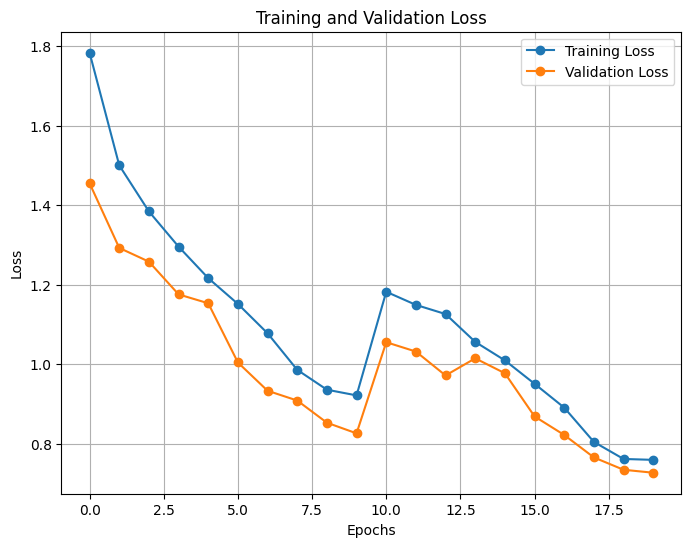

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
[[ 55   6   1   4   0   1   2   0   1]
 [  0  54   0   0   1   0   2   0   6]
 [  3   0  48   5   0   0   7   0   0]
 [  2   0   5  73  10   8  14   6   1]
 [  2  12   0   5  25   6  11  12   2]
 [  3   0   2   1   1  63   2   3   0]
 [  4   2   2  13   9   3 104   2   0]
 [  0   0   0   5  10   5   5  23   1]
 [  0   5   0   0   0   0   0   0  61]]


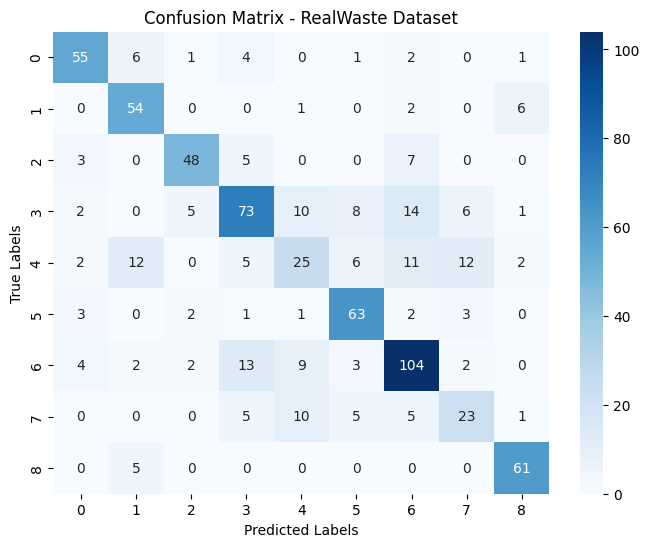

Classification Report:
              precision    recall  f1-score   support

           0     0.7971    0.7857    0.7914        70
           1     0.6835    0.8571    0.7606        63
           2     0.8276    0.7619    0.7934        63
           3     0.6887    0.6134    0.6489       119
           4     0.4464    0.3333    0.3817        75
           5     0.7326    0.8400    0.7826        75
           6     0.7075    0.7482    0.7273       139
           7     0.5000    0.4694    0.4842        49
           8     0.8472    0.9242    0.8841        66

    accuracy                         0.7038       719
   macro avg     0.6923    0.7037    0.6949       719
weighted avg     0.6956    0.7038    0.6968       719



In [23]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------
# Load the saved model
# ------------------------------
model_path = 'CNN_Adam.pth'
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

# ------------------------------
# Collect predictions and labels
# ------------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - RealWaste Dataset")
plt.show()

# ------------------------------
# Classification Report
# ------------------------------
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


# Training Using SGD


In [14]:
criterion = nn.CrossEntropyLoss() #CrossEntropyLoss
# Standard SGD (no momentum)
optimizer_sgd = optim.SGD(
    model.parameters(),
    lr=0.001,        # learning rate
    weight_decay=1e-4 # L2 regularization
)

# Scheduler for SGD
scheduler_sgd = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_sgd,
    T_0=10,
    T_mult=1,
    eta_min=1e-6
)

print("✅ Standard SGD optimizer and scheduler initialized!")


✅ Standard SGD optimizer and scheduler initialized!


In [15]:
num_epochs = 20
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train','val']:
        if phase=='train':
            model.train()
        else:
            model.eval()

        running_loss, running_corrects = 0.0, 0
        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase=='train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs,1)
                loss = criterion(outputs, labels)
                if phase=='train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item()*inputs.size(0)
            running_corrects += torch.sum(preds==labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        if phase=='train':
            scheduler.step()  # only once per epoch, not per batch
            train_losses.append(epoch_loss)
        else:
            val_losses.append(epoch_loss)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase=='val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())


print(f'Best validation Accuracy: {best_acc:.4f}')
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'CNN_SGD.pth')


Epoch 1/20
train Loss: 1.0164 Acc: 0.6392
val Loss: 1.0211 Acc: 0.6507
Epoch 2/20
train Loss: 1.0322 Acc: 0.6268
val Loss: 0.9172 Acc: 0.6507
Epoch 3/20
train Loss: 0.9538 Acc: 0.6666
val Loss: 1.0839 Acc: 0.6254
Epoch 4/20
train Loss: 0.9422 Acc: 0.6500
val Loss: 0.8303 Acc: 0.6930
Epoch 5/20
train Loss: 0.8791 Acc: 0.6840
val Loss: 0.8687 Acc: 0.6817
Epoch 6/20
train Loss: 0.8082 Acc: 0.7102
val Loss: 0.8463 Acc: 0.6972
Epoch 7/20
train Loss: 0.7843 Acc: 0.7171
val Loss: 0.6898 Acc: 0.7437
Epoch 8/20
train Loss: 0.7090 Acc: 0.7394
val Loss: 0.6586 Acc: 0.7592
Epoch 9/20
train Loss: 0.6423 Acc: 0.7665
val Loss: 0.6489 Acc: 0.7662
Epoch 10/20
train Loss: 0.6301 Acc: 0.7743
val Loss: 0.6413 Acc: 0.7718
Epoch 11/20
train Loss: 0.9181 Acc: 0.6693
val Loss: 0.9227 Acc: 0.6648
Epoch 12/20
train Loss: 0.8912 Acc: 0.6807
val Loss: 0.7937 Acc: 0.7197
Epoch 13/20
train Loss: 0.8730 Acc: 0.6822
val Loss: 0.9616 Acc: 0.6859
Epoch 14/20
train Loss: 0.7756 Acc: 0.7213
val Loss: 0.7393 Acc: 0.7225
E

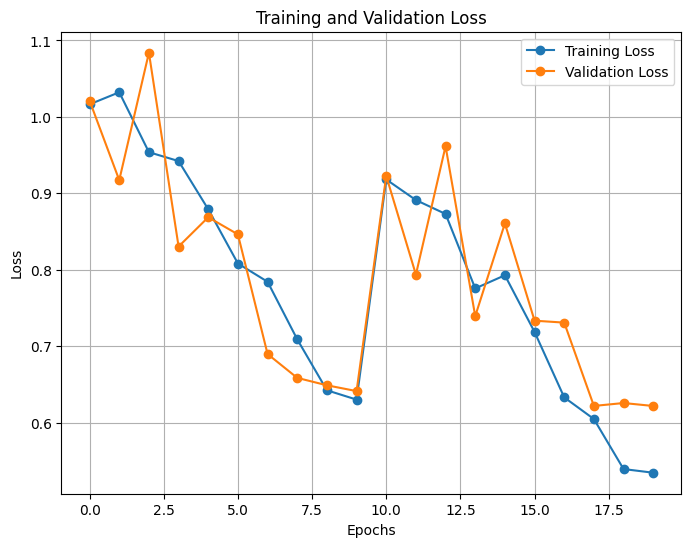

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
[[ 52   4   1   5   1   2   3   2   0]
 [  0  55   0   0   0   0   1   0   7]
 [  1   0  52   3   1   0   6   0   0]
 [  1   0   4  87   7   6   8   4   2]
 [  1   9   0   3  42   4  12   3   1]
 [  2   0   1   1   2  61   6   2   0]
 [  2   1   2  20   5   0 107   2   0]
 [  0   0   0   5   9   2   4  29   0]
 [  0   4   0   0   0   0   0   0  62]]


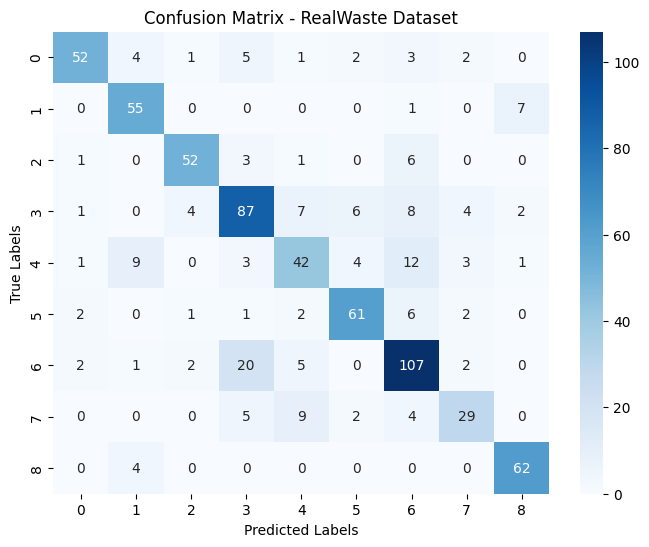

Classification Report:
              precision    recall  f1-score   support

           0     0.8814    0.7429    0.8062        70
           1     0.7534    0.8730    0.8088        63
           2     0.8667    0.8254    0.8455        63
           3     0.7016    0.7311    0.7160       119
           4     0.6269    0.5600    0.5915        75
           5     0.8133    0.8133    0.8133        75
           6     0.7279    0.7698    0.7483       139
           7     0.6905    0.5918    0.6374        49
           8     0.8611    0.9394    0.8986        66

    accuracy                         0.7608       719
   macro avg     0.7692    0.7607    0.7629       719
weighted avg     0.7609    0.7608    0.7591       719



In [18]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------
# Load the saved model
# ------------------------------
model_path = 'CNN_SGD.pth'
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

# ------------------------------
# Collect predictions and labels
# ------------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - RealWaste Dataset")
plt.show()

# ------------------------------
# Classification Report
# ------------------------------
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


# Training Using SGD Momentum

In [19]:
# SGD with Momentum
optimizer_sgdm = optim.SGD(
    model.parameters(),
    lr=0.001,        # learning rate
    momentum=0.9,    # momentum factor
    weight_decay=1e-4
)

# Scheduler for SGD with Momentum
scheduler_sgdm = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_sgdm,
    T_0=10,
    T_mult=1,
    eta_min=1e-6
)

print("✅ SGD with Momentum optimizer and scheduler initialized!")


✅ SGD with Momentum optimizer and scheduler initialized!


In [20]:
num_epochs = 20
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train','val']:
        if phase=='train':
            model.train()
        else:
            model.eval()

        running_loss, running_corrects = 0.0, 0
        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase=='train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs,1)
                loss = criterion(outputs, labels)
                if phase=='train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item()*inputs.size(0)
            running_corrects += torch.sum(preds==labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        if phase=='train':
            scheduler.step()  # only once per epoch, not per batch
            train_losses.append(epoch_loss)
        else:
            val_losses.append(epoch_loss)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase=='val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())


print(f'Best validation Accuracy: {best_acc:.4f}')
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'CNN_SGD_Momen.pth')


Epoch 1/20
train Loss: 0.8107 Acc: 0.7090
val Loss: 0.8376 Acc: 0.7070
Epoch 2/20
train Loss: 0.8038 Acc: 0.7042
val Loss: 0.7945 Acc: 0.7028
Epoch 3/20
train Loss: 0.8173 Acc: 0.7036
val Loss: 0.7444 Acc: 0.7437
Epoch 4/20
train Loss: 0.7114 Acc: 0.7472
val Loss: 0.8179 Acc: 0.7197
Epoch 5/20
train Loss: 0.6697 Acc: 0.7641
val Loss: 0.7167 Acc: 0.7408
Epoch 6/20
train Loss: 0.6072 Acc: 0.7788
val Loss: 0.7130 Acc: 0.7423
Epoch 7/20
train Loss: 0.5398 Acc: 0.8068
val Loss: 0.6250 Acc: 0.7704
Epoch 8/20
train Loss: 0.5450 Acc: 0.8110
val Loss: 0.6269 Acc: 0.7775
Epoch 9/20
train Loss: 0.4869 Acc: 0.8240
val Loss: 0.6306 Acc: 0.7775
Epoch 10/20
train Loss: 0.4482 Acc: 0.8462
val Loss: 0.6189 Acc: 0.7958
Epoch 11/20
train Loss: 0.6989 Acc: 0.7532
val Loss: 0.7271 Acc: 0.7380
Epoch 12/20
train Loss: 0.7409 Acc: 0.7259
val Loss: 0.7512 Acc: 0.7183
Epoch 13/20
train Loss: 0.6979 Acc: 0.7520
val Loss: 0.7965 Acc: 0.7423
Epoch 14/20
train Loss: 0.6620 Acc: 0.7659
val Loss: 0.8114 Acc: 0.7338
E

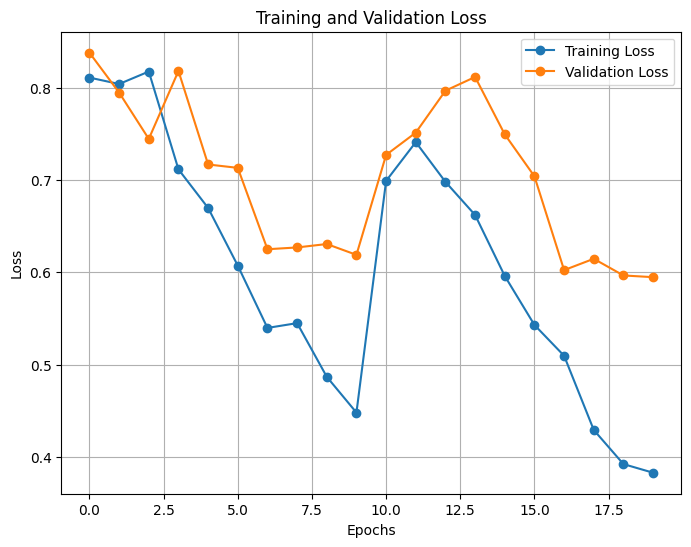

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
[[ 55   3   2   2   0   3   3   2   0]
 [  0  52   0   0   1   0   1   0   9]
 [  2   0  53   4   0   0   4   0   0]
 [  0   0   5  85   8   7   9   3   2]
 [  2   6   0   0  43   5  10   7   2]
 [  1   0   1   0   1  63   3   5   1]
 [  2   2   0  14   7   1 110   3   0]
 [  0   0   0   3   5   1   4  36   0]
 [  0   4   0   0   0   0   0   0  62]]


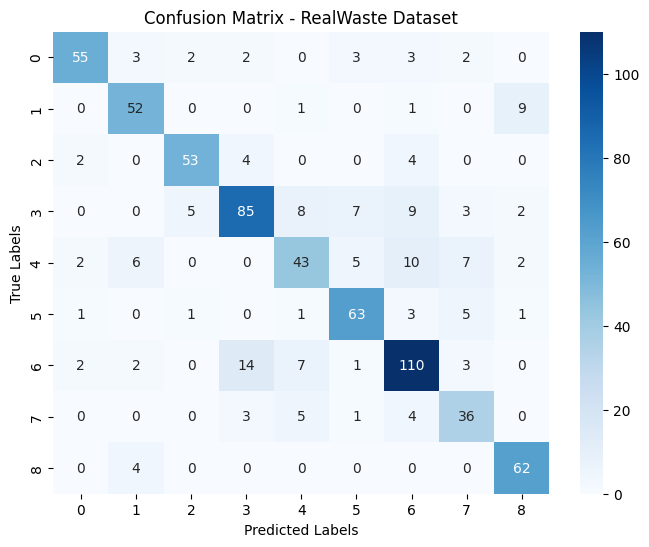

Classification Report:
              precision    recall  f1-score   support

           0     0.8871    0.7857    0.8333        70
           1     0.7761    0.8254    0.8000        63
           2     0.8689    0.8413    0.8548        63
           3     0.7870    0.7143    0.7489       119
           4     0.6615    0.5733    0.6143        75
           5     0.7875    0.8400    0.8129        75
           6     0.7639    0.7914    0.7774       139
           7     0.6429    0.7347    0.6857        49
           8     0.8158    0.9394    0.8732        66

    accuracy                         0.7775       719
   macro avg     0.7767    0.7828    0.7778       719
weighted avg     0.7783    0.7775    0.7761       719



In [22]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------
# Load the saved model
# ------------------------------
model_path = 'CNN_SGD_Momen.pth'
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

# ------------------------------
# Collect predictions and labels
# ------------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - RealWaste Dataset")
plt.show()

# ------------------------------
# Classification Report
# ------------------------------
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))
